In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
import time as t 
import random as rnd

seed = 42
rnd.seed(seed)
np.random.seed(seed)

print(f"Imported at: {t.ctime()}")

Imported at: Sun Mar 15 00:09:21 2026


In [34]:
results = "MPNN_results_heldout_set.csv"
df_results = pd.read_csv(results)
print(df_results.head())

names = ["0%", "33%", "67%"]

"""
Columns are: ["Dataset","Fold","Val_RMSE", "Val_MAE", "Val_Pearson", "Holdout_MSE", "Holdout_RMSE", "Holdout_MAE", "Holdout_R2", "Holdout_Rho", "Holdout_Pearson"]
What presentage synthetic they are from is in:

Dataset: "0%", "33%", "67%"
"""

zero_percent = df_results[df_results["Dataset"] == "0%"]
thirtythree_percent = df_results[df_results["Dataset"] == "33%"]
sixtyseven_percent = df_results[df_results["Dataset"] == "67%"]



  Dataset  Fold             Checkpoint  Val_RMSE   Val_MAE  Val_Pearson  \
0      0%     0  best_model_fold_0.pth  0.738975  0.576978     0.871751   
1      0%     1  best_model_fold_1.pth  0.657926  0.521863     0.840130   
2      0%     2  best_model_fold_2.pth  0.796979  0.627271     0.800848   
3      0%     3  best_model_fold_3.pth  0.805675  0.613884     0.821270   
4      0%     4  best_model_fold_4.pth  0.860390  0.654486     0.795398   

   Holdout_MSE  Holdout_RMSE  Holdout_MAE  Holdout_R2  Holdout_Rho  \
0     0.521144      0.721903     0.554731    0.514178     0.675358   
1     0.498883      0.706317     0.555356    0.534930     0.690817   
2     0.463211      0.680596     0.572891    0.568185     0.704726   
3     0.487101      0.697926     0.563406    0.545914     0.692152   
4     0.576704      0.759410     0.630195    0.462384     0.640647   

   Holdout_Pearson  
0         0.741012  
1         0.742763  
2         0.768199  
3         0.748109  
4         0.690569  


Plotting dataset from folder=./0%, file=MPNN_losses_0%.txt


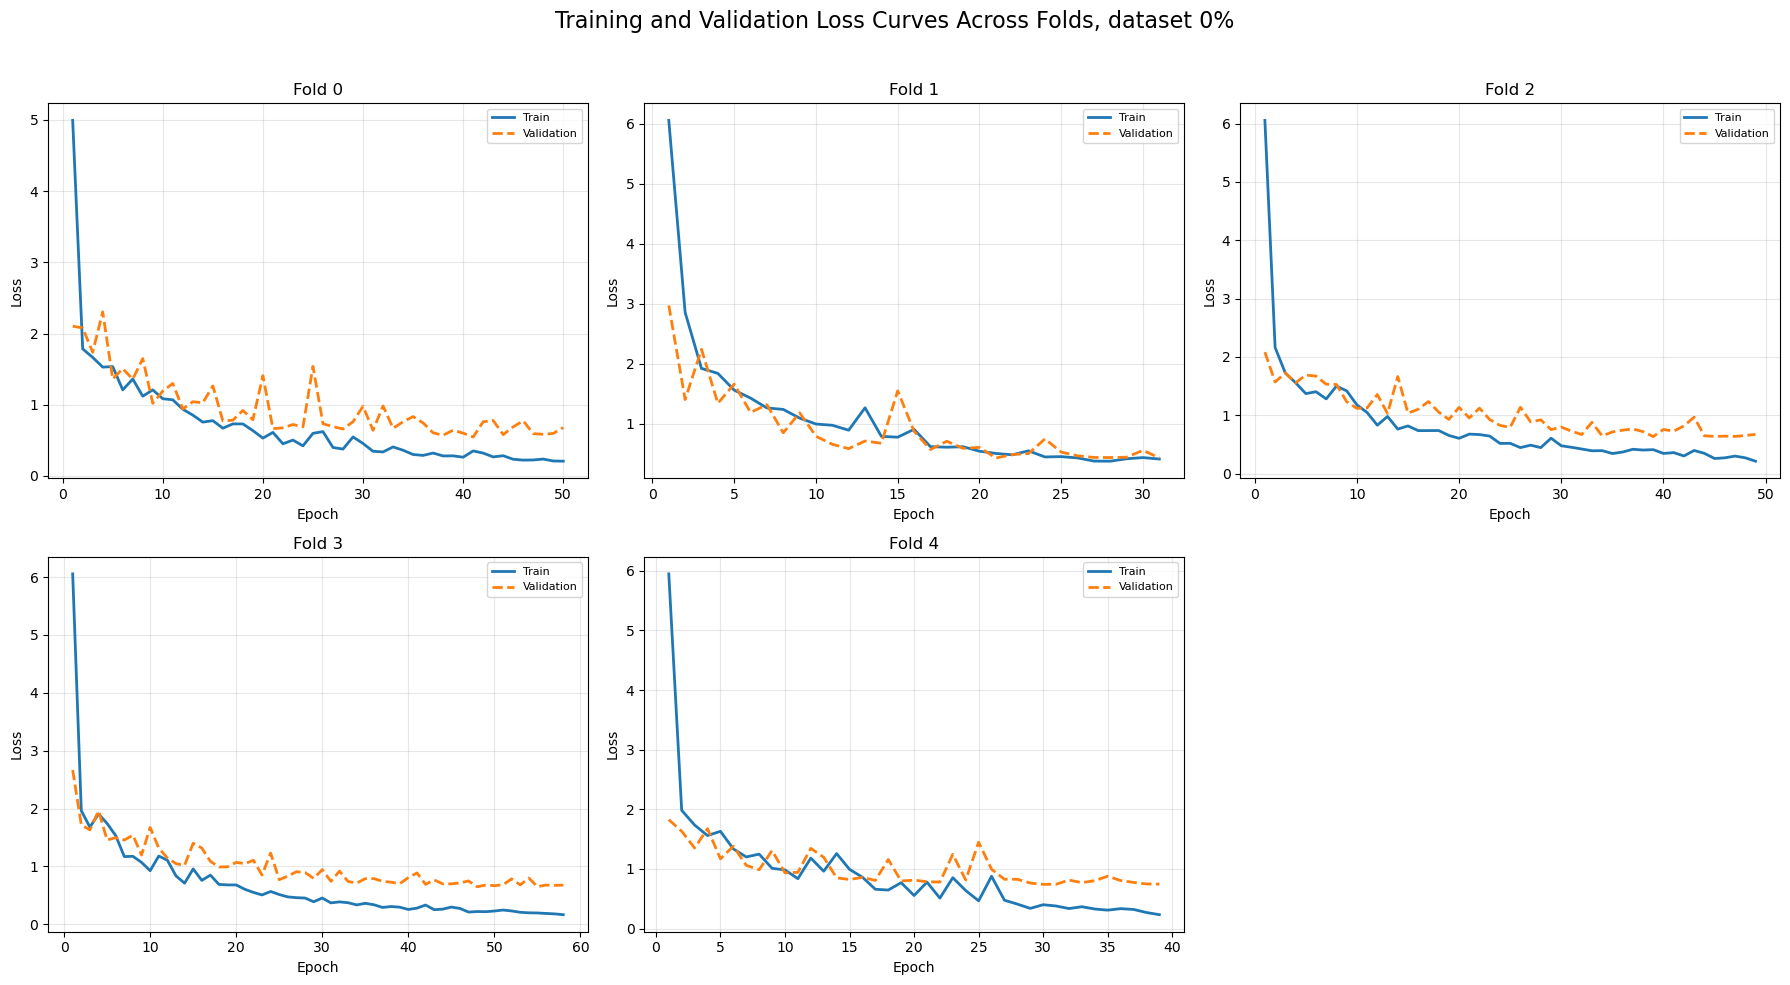

Plotting dataset from folder=./33%, file=MPNN_losses_33%.txt


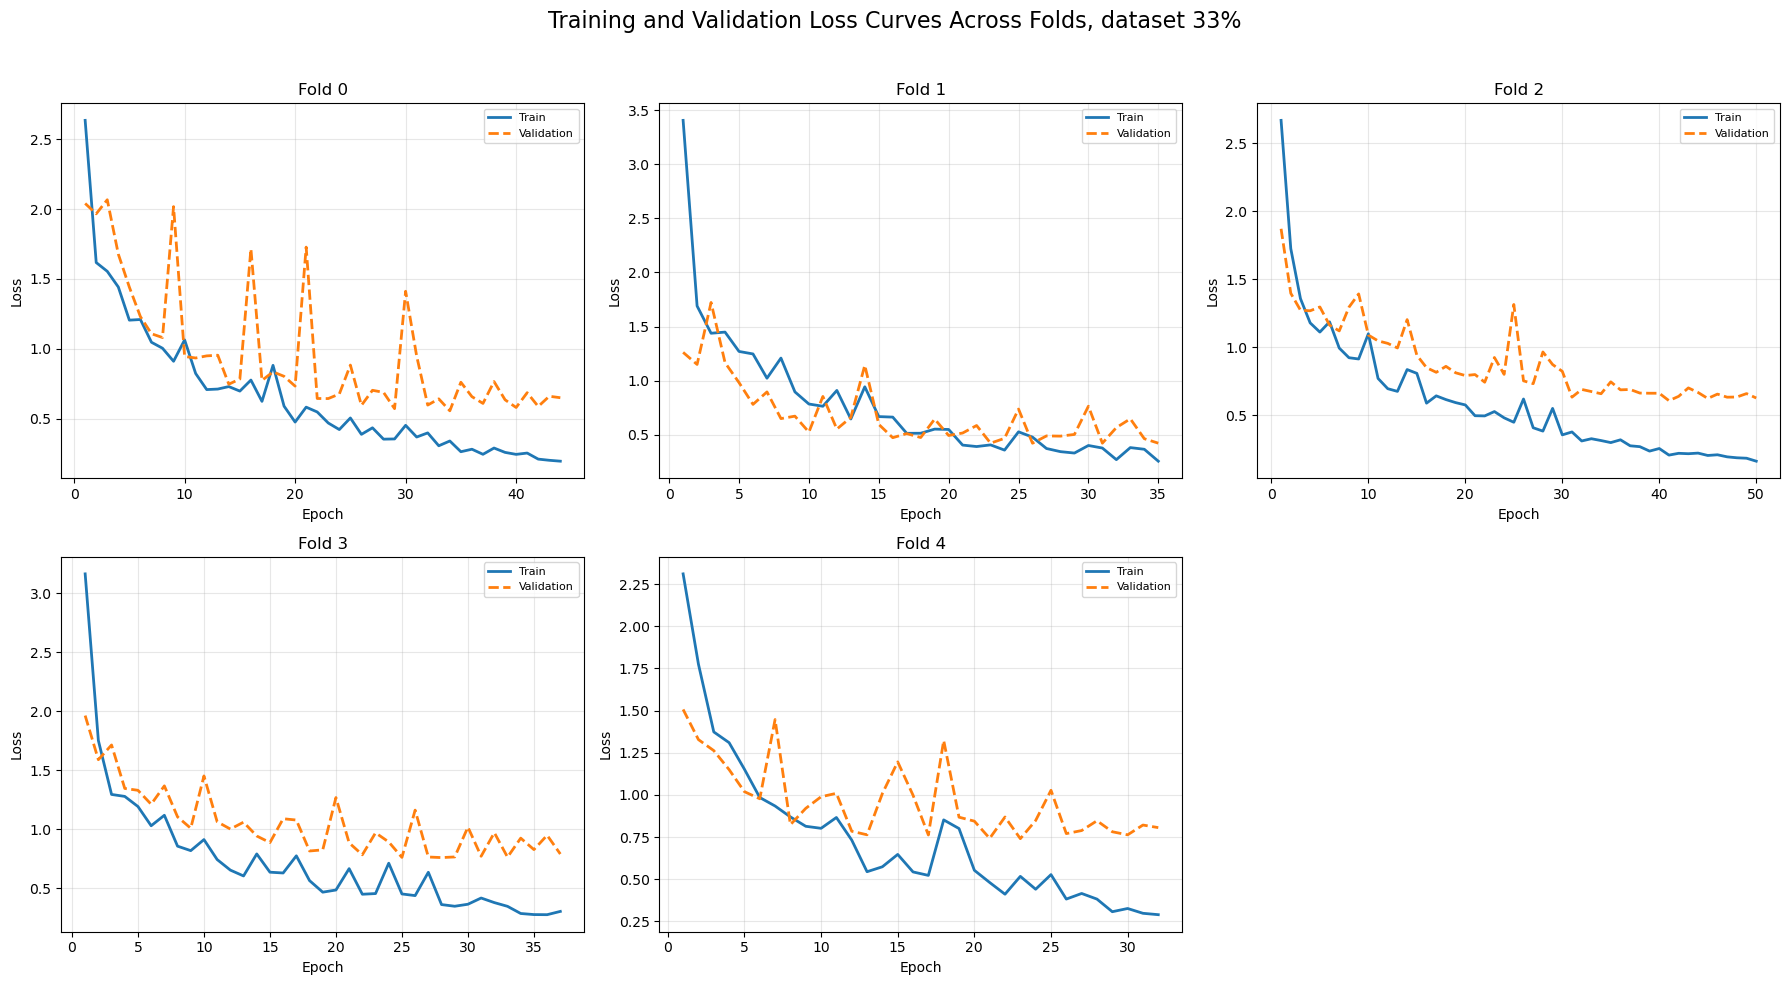

Plotting dataset from folder=./67%, file=MPNN_losses_67%.txt


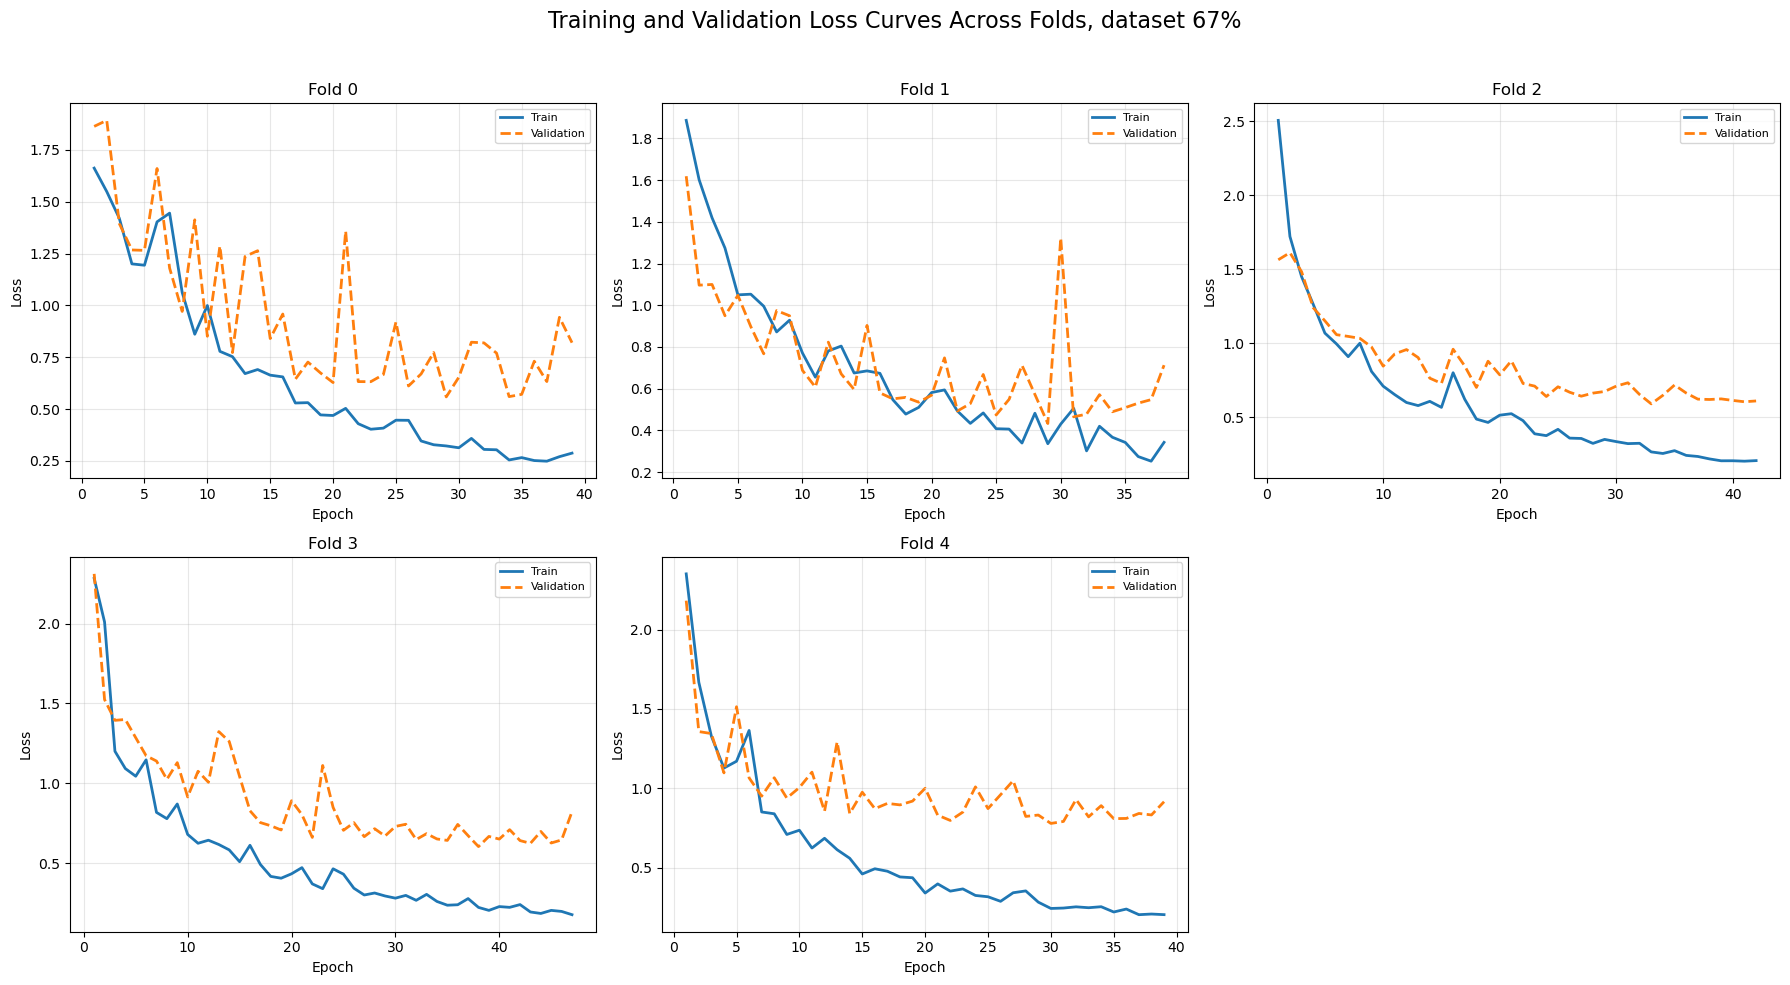

In [35]:
import os
import io
import re
import pandas as pd
import matplotlib.pyplot as plt


folders = ["./0%", "./33%", "./67%"]
path_in_folder = ["MPNN_losses_0%.txt", "MPNN_losses_33%.txt", "MPNN_losses_67%.txt"]


def load_fold_loss_file(file_path: str) -> dict[int, pd.DataFrame]:
    """
    Read a custom loss file with sections like:

    fold_0:
       train      val  monitor       lr
    5.560307 2.158475 1.469175 0.001000
    ...

    fold_1:
       train      val  monitor       lr
    ...

    Returns:
        dict mapping fold index -> DataFrame with columns:
        ['train', 'val', 'monitor', 'lr']
    """
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Split on lines like "fold_0:", "fold_1:", ...
    parts = re.split(r"(fold_\d+:)\s*", text)

    fold_data = {}

    # parts looks like:
    # [text_before, 'fold_0:', content0, 'fold_1:', content1, ...]
    for i in range(1, len(parts), 2):
        fold_header = parts[i].strip()
        fold_block = parts[i + 1].strip()

        match = re.match(r"fold_(\d+):", fold_header)
        if not match:
            continue

        fold_idx = int(match.group(1))

        # Remove empty lines inside block
        lines = [line.rstrip() for line in fold_block.splitlines() if line.strip()]
        if not lines:
            continue

        # Rebuild mini-table text for pandas
        block_text = "\n".join(lines)

        # Parse whitespace-separated mini table
        df = pd.read_csv(io.StringIO(block_text), sep=r"\s+")


        fold_data[fold_idx] = df

    return fold_data


def plot_loss_curves_subplots(
    folder: str,
    filename: str,
    max_folds: int = 5,
    figsize: tuple[int, int] = (18, 10),
):
    """
    Plot one dataset in one large figure with 5 smaller subplots,
    one subplot per fold.

    Parameters
    ----------
    folder : str
        Folder containing the loss file, for example "./0%".
    filename : str
        Name of the loss file, for example "MPNN_losses_0%.txt".
    max_folds : int
        Number of folds to plot.
    figsize : tuple[int, int]
        Figure size.
    """
    file_path = os.path.join(folder, filename)

    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found. Skipping this dataset.")
        return

    try:
        fold_data = load_fold_loss_file(file_path)
    except Exception as e:
        print(f"Warning: failed to parse {file_path}: {e}")
        return

    if not fold_data:
        print(f"No valid fold data found in {file_path}.")
        return

    dataset_label = os.path.basename(os.path.normpath(folder))

    # Create 2x3 grid, hide the last subplot if only 5 folds
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for fold_idx in range(max_folds):
        ax = axes[fold_idx]

        if fold_idx not in fold_data:
            ax.set_title(f"Fold {fold_idx} (missing)")
            ax.axis("off")
            continue

        df = fold_data[fold_idx]
        epochs = range(1, len(df) + 1)

        ax.plot(epochs, df["train"], label="Train", linewidth=2)
        ax.plot(epochs, df["val"], label="Validation", linestyle="--", linewidth=2)

        ax.set_title(f"Fold {fold_idx}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # Hide unused axes
    for i in range(max_folds, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        f"Training and Validation Loss Curves Across Folds, dataset {dataset_label}",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def iterate_datasets(
    folders: list[str],
    filenames: list[str],
    max_folds: int = 5,
    figsize: tuple[int, int] = (18, 10),
):
    """
    Iterate over datasets and plot one figure per dataset.

    Parameters
    ----------
    folders : list[str]
        Dataset folders, for example ["./0%", "./33%", "./67%"].
    filenames : list[str]
        Matching filenames for each folder.
    max_folds : int
        Number of folds to plot.
    figsize : tuple[int, int]
        Figure size.
    """
    if len(folders) != len(filenames):
        raise ValueError("folders and filenames must have the same length.")

    for folder, filename in zip(folders, filenames):
        print(f"Plotting dataset from folder={folder}, file={filename}")
        plot_loss_curves_subplots(
            folder=folder,
            filename=filename,
            max_folds=max_folds,
            figsize=figsize,
        )


iterate_datasets(folders, path_in_folder)

  Dataset  Fold             Checkpoint  Val_RMSE   Val_MAE  Val_Pearson  \
0      0%     0  best_model_fold_0.pth  0.738975  0.576978     0.871751   
1      0%     1  best_model_fold_1.pth  0.657926  0.521863     0.840130   
2      0%     2  best_model_fold_2.pth  0.796979  0.627271     0.800848   
3      0%     3  best_model_fold_3.pth  0.805675  0.613884     0.821270   
4      0%     4  best_model_fold_4.pth  0.860390  0.654486     0.795398   

   Holdout_MSE  Holdout_RMSE  Holdout_MAE  Holdout_R2  Holdout_Rho  \
0     0.521144      0.721903     0.554731    0.514178     0.675358   
1     0.498883      0.706317     0.555356    0.534930     0.690817   
2     0.463211      0.680596     0.572891    0.568185     0.704726   
3     0.487101      0.697926     0.563406    0.545914     0.692152   
4     0.576704      0.759410     0.630195    0.462384     0.640647   

   Holdout_Pearson  
0         0.741012  
1         0.742763  
2         0.768199  
3         0.748109  
4         0.690569  
['

C:\Users\kjo02\AppData\Local\Temp\ipykernel_15764\45695836.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_15764\45695836.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_15764\45695836.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_15764\45695836.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

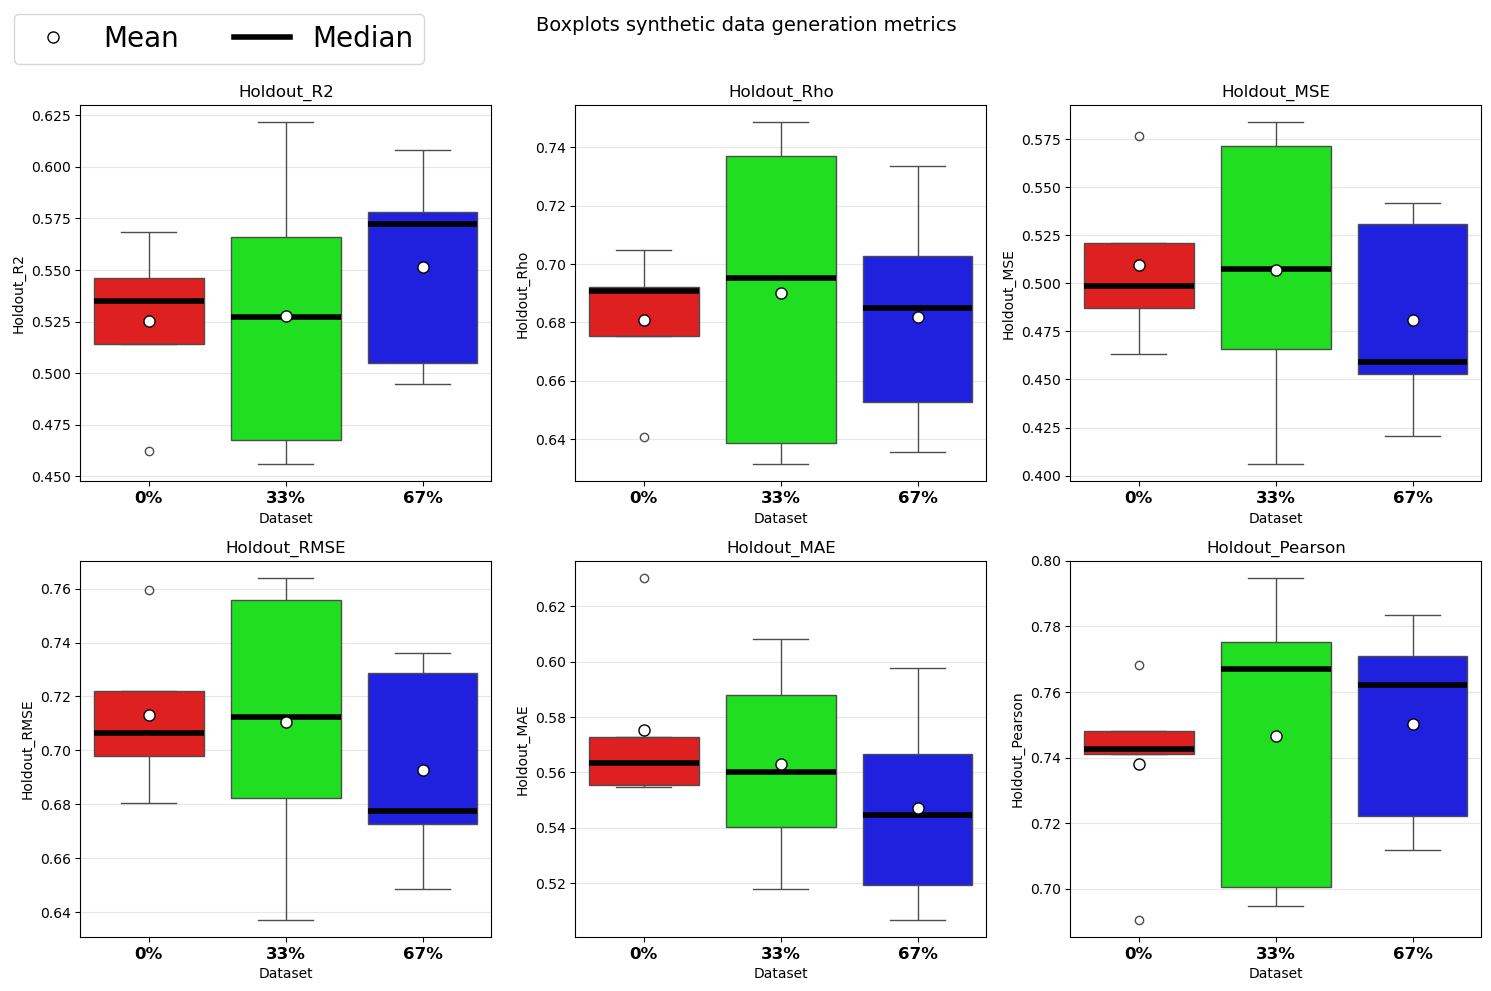

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


results = "MPNN_results_heldout_set.csv"
df_results = pd.read_csv(results)

print(df_results.head())
print(df_results.columns.tolist())

names = ["0%", "33%", "67%"]


def simple_metric_boxplots(df: pd.DataFrame, metrics: str | list[str], title: str = "Boxplots"):
    if isinstance(metrics, str):
        metrics = [metrics]

    amount = len(metrics)
    n_per_row = min(3, amount)  # max 3 plots per row for better aesthetics
    rows = (amount + n_per_row - 1) // n_per_row  # calculate number of rows needed
    fig, axs = plt.subplots(rows, n_per_row, figsize=(5 * n_per_row, 5 * rows)) # Adjust figure size based on number of plots

    if len(metrics) == 1:
        axs = [axs]
    
    

    axs = np.atleast_1d(axs).flatten()
    plot_df = df[df["Dataset"].isin(names)].copy()

    colors = ['#FF0000', '#00FF00', '#0000FF']  # Red, Green, Blue for the three datasets
    #colors = sns.color_palette("tab10", n_colors=len(metrics))  # Seaborn Set2 palette for better aesthetics
    idx = 0
    for ax, metric in zip(axs, metrics):
        if metric not in plot_df.columns:
            ax.set_visible(False)
            print(f"Warning: metric '{metric}' not found in dataframe columns.")
            continue

        
        mean_handle = Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='white',
            markeredgecolor='black',
            markersize=8,
            label='Mean'
        )

        median_handle = Line2D(
            [0], [0],
            color='black',
            linewidth=4,
            label='Median'
        )
        sns.boxplot(
            x="Dataset",
            y=metric,
            data=plot_df,
            order=names,
            ax=ax,
            showfliers=True,
            palette=colors,
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
            medianprops={
                "linewidth": 4,
                "color": "black"
            }
        )
        
        ax.set_title(metric)
        ax.set_xlabel("Dataset")
        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.3)
        for label in ax.get_xticklabels():
            label.set_fontsize(12)
            label.set_fontweight('bold')
    # Hide any unused subplot axes
    for ax in axs[len(metrics):]:
        ax.set_visible(False)
    fig.legend(
        handles=[mean_handle, median_handle],
        loc='upper left',
        ncol=3,
        fontsize=20,
        frameon=True
    )
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300)  # Save the figure as a high-resolution PNG file
    plt.show()


"""
Columns are: ["Dataset","Fold","Val_RMSE", "Val_MAE", "Val_Pearson", "Holdout_MSE", "Holdout_RMSE", "Holdout_MAE", "Holdout_R2", "Holdout_Rho", "Holdout_Pearson"]
What presentage synthetic they are from is in:

Dataset: "0%", "33%", "67%"
"""

simple_metric_boxplots(
    df_results,
    ["Holdout_R2", "Holdout_Rho", "Holdout_MSE","Holdout_RMSE", "Holdout_MAE", "Holdout_Pearson"],
    title="Boxplots synthetic data generation metrics"
)

Loaded prediction file
Shape: (3000, 9)
Unique datasets: ['0%', '33%', '67%']
Unique folds: [0, 1, 2, 3, 4]
Unique molecules: 200

Row-level summary by dataset
Dataset  n_rows  n_unique_molecules  mean_abs_error     rmse
     0%    1000                 200        0.575316 0.713729
    33%    1000                 200        0.562834 0.711925
    67%    1000                 200        0.546971 0.693530

Molecule-level dataset summary
Dataset  n_molecules  mean_mae  median_mae  mean_rmse  median_rmse
     0%          200  0.575316    0.483644   0.620827     0.526643
    33%          200  0.562834    0.450402   0.619755     0.520151
    67%          200  0.546971    0.414317   0.588744     0.455749

Statistical tests
        Metric Dataset_A Dataset_B  n_molecules   Mean_A   Mean_B  Median_A  Median_B  Mean_diff_A_minus_B  Median_diff_A_minus_B  Wilcoxon_stat  Wilcoxon_p  Friedman_stat  Friedman_p  Wilcoxon_p_holm
mean_abs_error        0%       33%          200 0.575316 0.562834  0.483644 

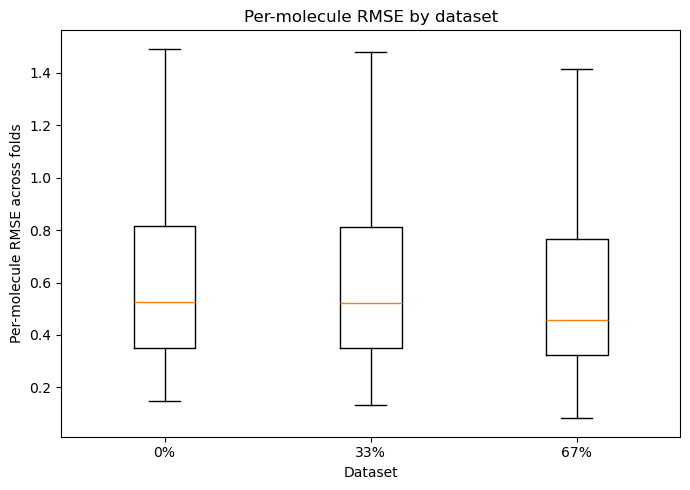

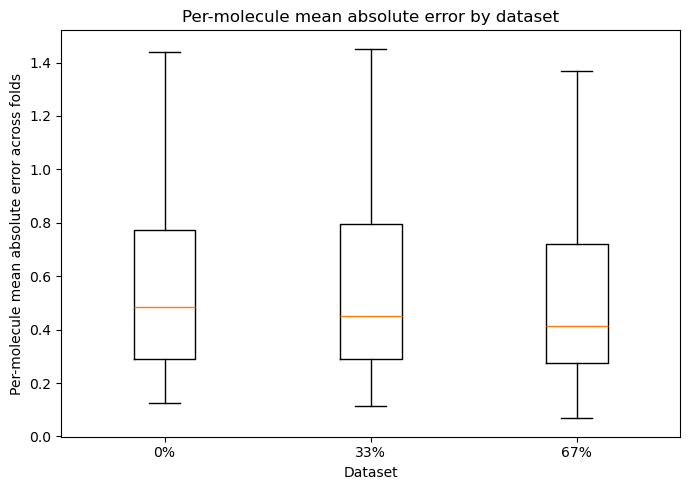

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, friedmanchisquare
from itertools import combinations


# ==============================================================================
# Configuration
# ==============================================================================

PREDICTIONS_CSV = "GAT_predictions_heldout_set.csv"
DATASET_ORDER = ["0%", "33%", "67%"]

# Keep only the main performance metrics
MOLECULE_LEVEL_METRICS = [
    "mean_abs_error",
    "rmse",
]


# ==============================================================================
# Utility functions
# ==============================================================================

def holm_correction(p_values: list[float]) -> list[float]:
    """
    Apply Holm correction to a list of p-values.

    Returns corrected p-values in the original order.
    """
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    sorted_p = p_values[order]

    adjusted = np.empty(n, dtype=float)

    running_max = 0.0
    for i, p in enumerate(sorted_p):
        adjusted_value = min((n - i) * p, 1.0)
        running_max = max(running_max, adjusted_value)
        adjusted[i] = running_max

    corrected = np.empty(n, dtype=float)
    corrected[order] = adjusted
    return corrected.tolist()


def load_and_prepare_predictions(predictions_csv: str) -> pd.DataFrame:
    """
    Load prediction CSV and compute row-level error quantities.
    """
    df = pd.read_csv(predictions_csv)

    required_cols = ["Dataset", "Fold", "smiles", "True_pIC50", "Pred_pIC50"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df["Fold"] = pd.to_numeric(df["Fold"], errors="raise")

    df["residual"] = df["Pred_pIC50"] - df["True_pIC50"]
    df["abs_error"] = df["residual"].abs()
    df["squared_error"] = df["residual"] ** 2

    return df


def summarize_row_level(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute compact row-level summaries by dataset.
    """
    row_summary = (
        df.groupby("Dataset", as_index=False)
        .agg(
            n_rows=("smiles", "size"),
            n_unique_molecules=("smiles", "nunique"),
            mean_abs_error=("abs_error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
        )
    )

    return row_summary


def aggregate_per_molecule_per_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate across folds to one row per molecule per dataset.
    """
    mol_dataset = (
        df.groupby(["smiles", "Dataset"], as_index=False)
        .agg(
            True_pIC50=("True_pIC50", "first"),
            mean_abs_error=("abs_error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
        )
    )

    return mol_dataset


def run_friedman_and_wilcoxon(
    mol_dataset: pd.DataFrame,
    dataset_order: list[str],
    metrics: list[str],
) -> pd.DataFrame:
    """
    For each molecule-level metric:
    1. Pivot to matched molecules across datasets
    2. Run Friedman test across all 3 datasets
    3. Run pairwise Wilcoxon signed-rank tests
    4. Apply Holm correction within each metric
    """
    results = []

    for metric in metrics:
        pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
        pivot = pivot[dataset_order].dropna()

        if len(pivot) == 0:
            print(f"[warning] No matched molecules found for metric: {metric}")
            continue

        friedman_stat, friedman_p = friedmanchisquare(
            pivot[dataset_order[0]].to_numpy(),
            pivot[dataset_order[1]].to_numpy(),
            pivot[dataset_order[2]].to_numpy(),
        )

        metric_rows = []

        for dataset_a, dataset_b in combinations(dataset_order, 2):
            x = pivot[dataset_a].to_numpy()
            y = pivot[dataset_b].to_numpy()
            diff = x - y

            try:
                wilcoxon_stat, wilcoxon_p = wilcoxon(
                    x,
                    y,
                    alternative="two-sided",
                    zero_method="wilcox",
                    correction=False,
                    mode="auto",
                )
            except ValueError:
                wilcoxon_stat = np.nan
                wilcoxon_p = np.nan

            metric_rows.append({
                "Metric": metric,
                "Dataset_A": dataset_a,
                "Dataset_B": dataset_b,
                "n_molecules": len(pivot),
                "Mean_A": np.mean(x),
                "Mean_B": np.mean(y),
                "Median_A": np.median(x),
                "Median_B": np.median(y),
                "Mean_diff_A_minus_B": np.mean(diff),
                "Median_diff_A_minus_B": np.median(diff),
                "Wilcoxon_stat": wilcoxon_stat,
                "Wilcoxon_p": wilcoxon_p,
                "Friedman_stat": friedman_stat,
                "Friedman_p": friedman_p,
            })

        corrected_p_values = holm_correction([row["Wilcoxon_p"] for row in metric_rows])

        for row, corrected_p in zip(metric_rows, corrected_p_values):
            row["Wilcoxon_p_holm"] = corrected_p
            results.append(row)

    return pd.DataFrame(results)


def build_improvement_table(mol_dataset: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Build a compact per-molecule improvement table for one metric.
    Positive values mean improvement because lower error is better.
    """
    pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
    pivot = pivot[DATASET_ORDER].dropna().copy()

    pivot["improvement_33_vs_0"] = pivot["0%"] - pivot["33%"]
    pivot["improvement_67_vs_0"] = pivot["0%"] - pivot["67%"]
    pivot["improvement_67_vs_33"] = pivot["33%"] - pivot["67%"]

    return pivot.reset_index()


def plot_metric_boxplot(
    mol_dataset: pd.DataFrame,
    dataset_order: list[str],
    metric: str,
    ylabel: str,
    title: str,
) -> None:
    """
    Plot molecule-level distribution for one metric.
    """
    data = [
        mol_dataset.loc[mol_dataset["Dataset"] == dataset_name, metric].to_numpy()
        for dataset_name in dataset_order
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(data, tick_labels=dataset_order, showfliers=False)
    plt.xlabel("Dataset")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ==============================================================================
# Main analysis
# ==============================================================================

def main() -> None:
    df = load_and_prepare_predictions(PREDICTIONS_CSV)

    print("=" * 80)
    print("Loaded prediction file")
    print("=" * 80)
    print("Shape:", df.shape)
    print("Unique datasets:", sorted(df["Dataset"].unique().tolist()))
    print("Unique folds:", sorted(df["Fold"].unique().tolist()))
    print("Unique molecules:", df["smiles"].nunique())

    # --------------------------------------------------------------------------
    # Compact row-level summary
    # --------------------------------------------------------------------------
    row_summary = summarize_row_level(df)

    print("\n" + "=" * 80)
    print("Row-level summary by dataset")
    print("=" * 80)
    print(row_summary.to_string(index=False))

    # --------------------------------------------------------------------------
    # Aggregate to one row per molecule per dataset
    # --------------------------------------------------------------------------
    mol_dataset = aggregate_per_molecule_per_dataset(df)

    print("\n" + "=" * 80)
    print("Molecule-level dataset summary")
    print("=" * 80)
    mol_summary = (
        mol_dataset.groupby("Dataset", as_index=False)
        .agg(
            n_molecules=("smiles", "nunique"),
            mean_mae=("mean_abs_error", "mean"),
            median_mae=("mean_abs_error", "median"),
            mean_rmse=("rmse", "mean"),
            median_rmse=("rmse", "median"),
        )
    )
    print(mol_summary.to_string(index=False))

    # --------------------------------------------------------------------------
    # Statistical tests on the only metrics that matter here
    # --------------------------------------------------------------------------
    stats_df = run_friedman_and_wilcoxon(
        mol_dataset=mol_dataset,
        dataset_order=DATASET_ORDER,
        metrics=MOLECULE_LEVEL_METRICS,
    )

    print("\n" + "=" * 80)
    print("Statistical tests")
    print("=" * 80)
    print(stats_df.to_string(index=False))

    # --------------------------------------------------------------------------
    # Improvement table for RMSE only
    # --------------------------------------------------------------------------
    rmse_improvement_df = build_improvement_table(mol_dataset, metric="rmse")

    print("\n" + "=" * 80)
    print("Top 10 molecules improved most in 67% vs 0% by RMSE")
    print("=" * 80)
    print(
        rmse_improvement_df
        .sort_values("improvement_67_vs_0", ascending=False)
        .loc[:, ["smiles", "0%", "33%", "67%", "improvement_67_vs_0"]]
        .head(10)
        .to_string(index=False)
    )

    # --------------------------------------------------------------------------
    # Keep only the two most useful plots
    # --------------------------------------------------------------------------
    plot_metric_boxplot(
        mol_dataset=mol_dataset,
        dataset_order=DATASET_ORDER,
        metric="rmse",
        ylabel="Per-molecule RMSE across folds",
        title="Per-molecule RMSE by dataset",
    )

    plot_metric_boxplot(
        mol_dataset=mol_dataset,
        dataset_order=DATASET_ORDER,
        metric="mean_abs_error",
        ylabel="Per-molecule mean absolute error across folds",
        title="Per-molecule mean absolute error by dataset",
    )


if __name__ == "__main__":
    main()